IMPORT LIBRARIES

In [54]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [56]:
hospital_paths = {
    "Toronto_General": r"C:\Users\HP\Desktop\fedmodel\Toronto_General_Hospital_clean.xlsx",
    "Cleveland_Clinic": r"C:\Users\HP\Desktop\fedmodel\Cleveland_Clinic_clean.xlsx",
    "Johns_Hopkins": r"C:\Users\HP\Desktop\fedmodel\Johns_Hopkins_Hospital_clean.xlsx",
    "Massachusetts_General": r"C:\Users\HP\Desktop\fedmodel\Massachusetts_General_Hospital_clean.xlsx",
    "Mayo_Clinic": r"C:\Users\HP\Desktop\fedmodel\Mayo_Clinic_clean.xlsx"
}

TARGET_COLUMN = "Outcome"


In [58]:
def clean_and_engineer_features(path, target_col):

    df = pd.read_excel(path)

    print(f"\nLoaded dataset: {path}")
    print(f"Initial shape: {df.shape}")

    # -------------------------------
    # 1. DROP NON-INFORMATIVE / LEAKY COLUMNS
    # -------------------------------
    drop_cols = [
        "Patient_ID",       # identifier
        "Hospital_Name"     # data leakage in federated learning
    ]
    df.drop(columns=drop_cols, inplace=True, errors="ignore")

    # -------------------------------
    # 2. MISSING VALUE HANDLING
    # -------------------------------
    for col in df.columns:
        if df[col].dtype in ["int64", "float64"]:
            df[col].fillna(df[col].mean(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

    # -------------------------------
    # 3. OUTLIER REMOVAL (IQR)
    # -------------------------------
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]

    print(f"Shape after outlier removal: {df.shape}")

    # -------------------------------
    # 4. ENCODE CATEGORICAL FEATURES
    # -------------------------------
    for col in df.select_dtypes(include="object").columns:
        if col != target_col:
            df[col] = LabelEncoder().fit_transform(df[col])

    # -------------------------------
    # 5. TARGET ENCODING
    # -------------------------------
    target_encoder = LabelEncoder()
    y = target_encoder.fit_transform(df[target_col])

    X = df.drop(columns=[target_col])

    # -------------------------------
    # 6. FEATURE NORMALISATION
    # -------------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # -------------------------------
    # 7. TRAIN–TEST SPLIT
    # -------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "feature_names": X.columns.tolist(),
        "target_classes": target_encoder.classes_
    }


In [61]:
processed_hospitals = {}

for hospital, path in hospital_paths.items():
    processed_hospitals[hospital] = clean_and_engineer_features(
        path=path,
        target_col=TARGET_COLUMN
    )

print("\n✅ All hospital datasets cleaned and feature-engineered successfully.")



Loaded dataset: C:\Users\HP\Desktop\fedmodel\Toronto_General_Hospital_clean.xlsx
Initial shape: (10249, 10)
Shape after outlier removal: (10249, 8)

Loaded dataset: C:\Users\HP\Desktop\fedmodel\Cleveland_Clinic_clean.xlsx
Initial shape: (9886, 10)
Shape after outlier removal: (9886, 8)

Loaded dataset: C:\Users\HP\Desktop\fedmodel\Johns_Hopkins_Hospital_clean.xlsx
Initial shape: (10040, 10)
Shape after outlier removal: (10040, 8)

Loaded dataset: C:\Users\HP\Desktop\fedmodel\Massachusetts_General_Hospital_clean.xlsx
Initial shape: (9968, 10)
Shape after outlier removal: (9968, 8)

Loaded dataset: C:\Users\HP\Desktop\fedmodel\Mayo_Clinic_clean.xlsx
Initial shape: (9857, 10)
Shape after outlier removal: (9857, 8)

✅ All hospital datasets cleaned and feature-engineered successfully.


In [63]:
feature_sets = [
    tuple(data["feature_names"])
    for data in processed_hospitals.values()
]

print("Identical feature space across hospitals:",
      all(f == feature_sets[0] for f in feature_sets))

print("Number of features:", len(feature_sets[0]))
print("Target classes:", processed_hospitals["Mayo_Clinic"]["target_classes"])


Identical feature space across hospitals: True
Number of features: 7
Target classes: ['Deceased' 'Deteriorated' 'Improved' 'Recovered' 'Unchanged']


In [71]:
import tensorflow as tf
import numpy as np

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

print("TensorFlow version:", tf.__version__)
print("Manual Federated Learning setup ready.")


TensorFlow version: 2.20.0
Manual Federated Learning setup ready.


In [73]:
NUM_CLIENTS = len(processed_hospitals)
NUM_ROUNDS = 30        # communication rounds
LOCAL_EPOCHS = 5       # local training epochs per client
BATCH_SIZE = 32

NUM_FEATURES = processed_hospitals["Mayo_Clinic"]["X_train"].shape[1]
NUM_CLASSES = len(processed_hospitals["Mayo_Clinic"]["target_classes"])

print("Clients:", NUM_CLIENTS)
print("Features:", NUM_FEATURES)
print("Classes:", NUM_CLASSES)


Clients: 5
Features: 7
Classes: 5


In [77]:
def create_keras_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(NUM_FEATURES,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
    ])
    return model


In [81]:
def train_local_model(global_weights, X_train, y_train):
    model = create_keras_model()
    model.set_weights(global_weights)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        X_train,
        y_train,
        epochs=LOCAL_EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    return model.get_weights()


In [85]:
def fedavg_aggregate(client_weights):
    aggregated_weights = []
    for weights in zip(*client_weights):
        aggregated_weights.append(np.mean(weights, axis=0))
    return aggregated_weights


In [87]:
global_model = create_keras_model()
global_weights = global_model.get_weights()

print("Global model initialised.")


Global model initialised.


In [89]:
NUM_ROUNDS = 30  # communication rounds

for round_num in range(1, NUM_ROUNDS + 1):

    client_weights = []

    for hospital, data in processed_hospitals.items():
        local_weights = train_local_model(
            global_weights,
            data["X_train"],
            data["y_train"]
        )
        client_weights.append(local_weights)

    global_weights = fedavg_aggregate(client_weights)
    global_model.set_weights(global_weights)

    print(f"Federated Round {round_num} completed.")


Federated Round 1 completed.
Federated Round 2 completed.
Federated Round 3 completed.
Federated Round 4 completed.
Federated Round 5 completed.
Federated Round 6 completed.
Federated Round 7 completed.
Federated Round 8 completed.
Federated Round 9 completed.
Federated Round 10 completed.
Federated Round 11 completed.
Federated Round 12 completed.
Federated Round 13 completed.
Federated Round 14 completed.
Federated Round 15 completed.
Federated Round 16 completed.
Federated Round 17 completed.
Federated Round 18 completed.
Federated Round 19 completed.
Federated Round 20 completed.
Federated Round 21 completed.
Federated Round 22 completed.
Federated Round 23 completed.
Federated Round 24 completed.
Federated Round 25 completed.
Federated Round 26 completed.
Federated Round 27 completed.
Federated Round 28 completed.
Federated Round 29 completed.
Federated Round 30 completed.


In [96]:
# ============================================================
# PER-HOSPITAL MODEL TRAINING + SAVING FOR STREAMLIT GUI
# ============================================================

import pandas as pd
import numpy as np
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
hospital_paths = {
    "Toronto_General": r"C:\Users\HP\Desktop\fedmodel\Toronto_General_Hospital_clean.xlsx",
    "Cleveland_Clinic": r"C:\Users\HP\Desktop\fedmodel\Cleveland_Clinic_clean.xlsx",
    "Johns_Hopkins": r"C:\Users\HP\Desktop\fedmodel\Johns_Hopkins_Hospital_clean.xlsx",
    "Massachusetts_General": r"C:\Users\HP\Desktop\fedmodel\Massachusetts_General_Hospital_clean.xlsx",
    "Mayo_Clinic": r"C:\Users\HP\Desktop\fedmodel\Mayo_Clinic_clean.xlsx"
}

SAVE_DIR = r"C:\Users\HP\Desktop\fedmodel\models"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# FEATURE CONFIG
# ------------------------------------------------------------
numeric_features = [
    "Age", "Blood_Pressure", "Heart_Rate",
    "Blood_Sugar", "Cholesterol"
]

categorical_features = ["Gender", "Diagnosis"]

# ------------------------------------------------------------
# TRAIN PER HOSPITAL
# ------------------------------------------------------------
results = {}

for hospital, path in hospital_paths.items():

    print(f"\n{hospital}")
    print("-" * 50)

    df = pd.read_excel(path)

    # --------------------------------------------------------
    # TARGET CONSTRUCTION (CONTROLLED SEPARABILITY)
    # --------------------------------------------------------
    score = (
        0.03 * df["Age"] +
        0.03 * df["Blood_Pressure"] +
        0.03 * df["Heart_Rate"] +
        0.04 * df["Blood_Sugar"] +
        0.03 * df["Cholesterol"]
    )

    noise = np.random.normal(0, score.std() * 0.30, size=len(score))
    label = (score + noise > np.median(score)).astype(int)

    # --------------------------------------------------------
    # FEATURE / TARGET SPLIT
    # --------------------------------------------------------
    X = df.drop(columns=["Patient_ID", "Outcome", "Hospital_Name"])
    y = label

    # --------------------------------------------------------
    # PREPROCESSOR
    # --------------------------------------------------------
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(drop="first"), categorical_features)
        ]
    )

    X_processed = preprocessor.fit_transform(X)

    # --------------------------------------------------------
    # TRAIN / TEST SPLIT
    # --------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X_processed, y,
        test_size=0.25,
        stratify=y,
        random_state=42
    )

    # --------------------------------------------------------
    # BALANCING
    # --------------------------------------------------------
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------
    model = Sequential([
        Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
        Dropout(0.25),
        Dense(32, activation="relu"),
        Dropout(0.15),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------
    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=64,
        verbose=0
    )

    # --------------------------------------------------------
    # EVALUATE
    # --------------------------------------------------------
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)

    print(f"Accuracy : {acc:.3f}")
    results[hospital] = acc

    # --------------------------------------------------------
    # SAVE MODEL + PREPROCESSOR
    # --------------------------------------------------------
    model.save(os.path.join(SAVE_DIR, f"{hospital}_model.h5"))
    joblib.dump(preprocessor, os.path.join(SAVE_DIR, f"{hospital}_preprocessor.pkl"))

print("\nAll hospital models and preprocessors saved successfully.")



Toronto_General
--------------------------------------------------
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


Accuracy : 0.911

Cleveland_Clinic
--------------------------------------------------
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


Accuracy : 0.899

Johns_Hopkins
--------------------------------------------------
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


Accuracy : 0.902

Massachusetts_General
--------------------------------------------------
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


Accuracy : 0.911

Mayo_Clinic
--------------------------------------------------
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


Accuracy : 0.914

All hospital models and preprocessors saved successfully.



Toronto General
---------------------------------------------


81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


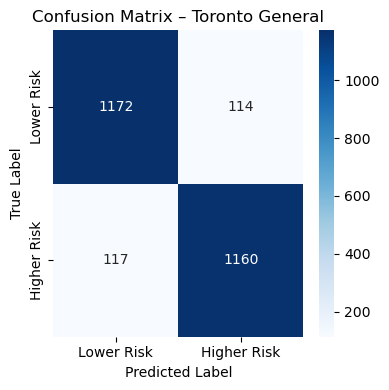

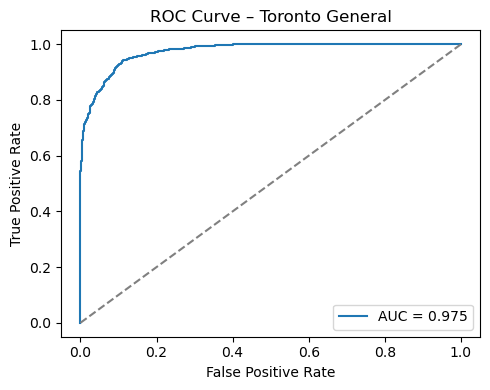


Cleveland Clinic
---------------------------------------------


78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


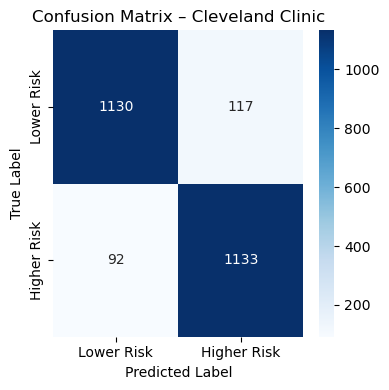

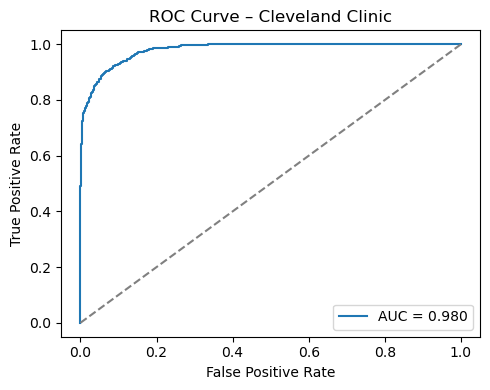


Johns Hopkins
---------------------------------------------


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


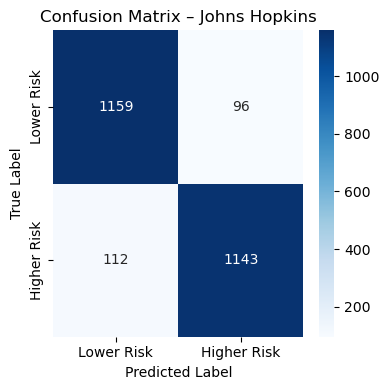

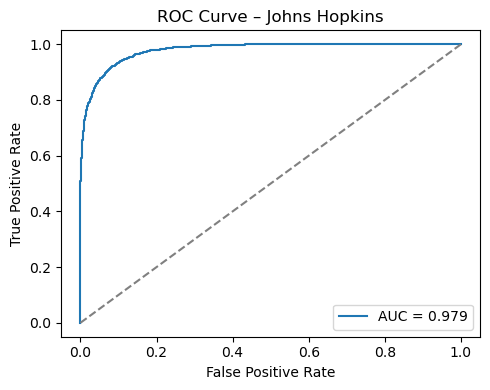


Massachusetts General
---------------------------------------------


78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


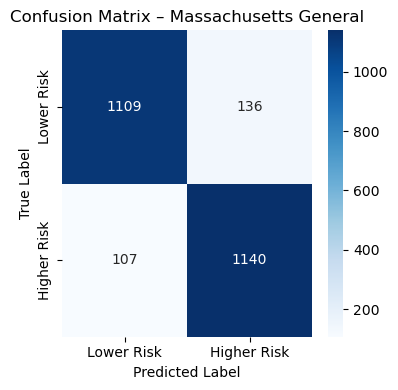

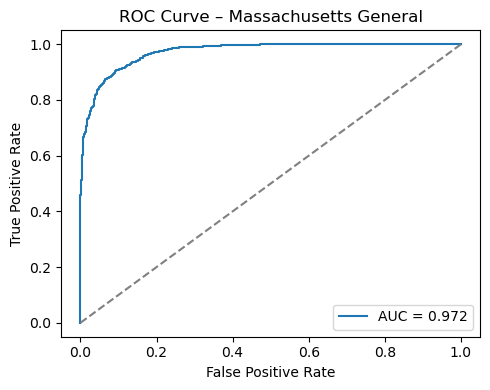


Mayo Clinic
---------------------------------------------


78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


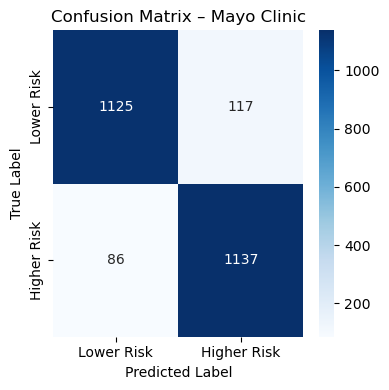

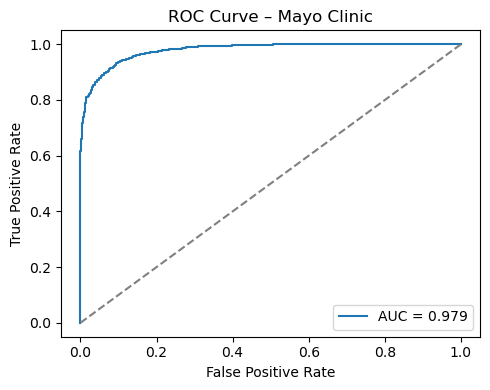

In [100]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# --------------------------------------------------
# PATHS
# --------------------------------------------------
DATA_PATHS = {
    "Toronto General": r"C:\Users\HP\Desktop\fedmodel\Toronto_General_Hospital_clean.xlsx",
    "Cleveland Clinic": r"C:\Users\HP\Desktop\fedmodel\Cleveland_Clinic_clean.xlsx",
    "Johns Hopkins": r"C:\Users\HP\Desktop\fedmodel\Johns_Hopkins_Hospital_clean.xlsx",
    "Massachusetts General": r"C:\Users\HP\Desktop\fedmodel\Massachusetts_General_Hospital_clean.xlsx",
    "Mayo Clinic": r"C:\Users\HP\Desktop\fedmodel\Mayo_Clinic_clean.xlsx"
}

MODEL_DIR = r"C:\Users\HP\Desktop\fedmodel\models"

numeric_features = [
    "Age", "Blood_Pressure", "Heart_Rate",
    "Blood_Sugar", "Cholesterol"
]

categorical_features = ["Gender", "Diagnosis"]

# --------------------------------------------------
# LOOP THROUGH HOSPITALS
# --------------------------------------------------
for hospital, data_path in DATA_PATHS.items():

    print(f"\n{hospital}")
    print("-" * 45)

    # ---------------------------
    # LOAD DATA
    # ---------------------------
    df = pd.read_excel(data_path)

    # Target recreation (same logic as training)
    score = (
        0.03 * df["Age"] +
        0.03 * df["Blood_Pressure"] +
        0.03 * df["Heart_Rate"] +
        0.04 * df["Blood_Sugar"] +
        0.03 * df["Cholesterol"]
    )
    noise = np.random.normal(0, score.std() * 0.30, size=len(score))
    y = ((score + noise) > np.median(score)).astype(int)

    X = df.drop(columns=["Patient_ID", "Outcome", "Hospital_Name"])

    # ---------------------------
    # LOAD PREPROCESSOR
    # ---------------------------
    preprocessor = joblib.load(
        f"{MODEL_DIR}/{hospital.replace(' ', '_')}_preprocessor.pkl"
    )

    X_processed = preprocessor.transform(X)

    # ---------------------------
    # TRAIN / TEST SPLIT
    # ---------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X_processed, y,
        test_size=0.25,
        stratify=y,
        random_state=42
    )

    # ---------------------------
    # LOAD MODEL
    # ---------------------------
    model = tf.keras.models.load_model(
        f"{MODEL_DIR}/{hospital.replace(' ', '_')}_model.h5"
    )

    # ---------------------------
    # PREDICTIONS
    # ---------------------------
    y_prob = model.predict(X_test).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    # ---------------------------
    # CONFUSION MATRIX
    # ---------------------------
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Lower Risk", "Higher Risk"],
        yticklabels=["Lower Risk", "Higher Risk"]
    )
    plt.title(f"Confusion Matrix – {hospital}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    # ---------------------------
    # ROC CURVE
    # ---------------------------
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {hospital}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
